# Naive Bayes — Vietnamese Toxic Comment Detection

## Thông tin bài tập lớn

- **Môn học:** Trí tuệ nhân tạo — Học viện Công nghệ Bưu chính Viễn thông (PTIT)
- **Tài liệu:** Russell, S. & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th Edition), Pearson Education.
- **Bài tập lớn:** Hệ thống phát hiện bình luận độc hại tiếng Việt.
- **Thành viên nhóm:**
  - Neural MLP: [đồng đội]
  - Naive Bayes: [em — phụ trách phần này]
- **Dataset:** ViHSD (Vietnamese Hate Speech Detection), 3 lớp: clean (0), hate (1), offensive (2).

## Mục tiêu notebook này

Trình bày lý thuyết và hiện thực Multinomial Naive Bayes (chương probabilistic reasoning — AIMA) để phân loại 3 lớp. Kết quả: lưu model artifact có thể dùng cho inference.

## 1. Lý thuyết: Multinomial Naive Bayes (AIMA, chương 13-20)

### 1.1. Bài toán phân loại Bayes tối ưu

Theo AIMA, **Bayes classifier tối ưu** chọn lớp có xác suất hậu nghiệm lớn nhất:

$$c^* = \arg\max_{c \in C} P(c \mid x_1, x_2, \dots, x_n)$$

Áp dụng **Bayes' theorem**:

$$P(c \mid \mathbf{x}) = \frac{P(c) \cdot P(\mathbf{x} \mid c)}{P(\mathbf{x})}$$

Vì $P(\mathbf{x})$ không phụ thuộc $c$, ta được:

$$c^* = \arg\max_{c} \underbrace{P(c)}_{\text{prior}} \cdot \underbrace{P(\mathbf{x} \mid c)}_{\text{likelihood}}$$

### 1.2. Naive Bayes assumption

$P(\mathbf{x} \mid c)$ rất khó ước lượng trực tiếp (curse of dimensionality). AIMA chấp nhận **naive conditional independence assumption**:

$$P(x_1, x_2, \dots, x_n \mid c) = \prod_{i=1}^{n} P(x_i \mid c)$$

Sai số do giả định này thường không tệ như tưởng tượng — AIMA Section 12.6 (trong 3rd) chứng minh nó vẫn là **optimal Bayes classifier** trong một số mô hình phái sinh (với class conditional independence đúng hoàn toàn).

### 1.3. Multinomial Naive Bayes cho text

Với document $\mathbf{x} = (x_1, x_2, \dots, x_n)$ gồm $n$ token, mỗi $x_i$ là word ID:

$$\hat{P}(c) = \frac{\text{count}(c)}{N}$$

$$\hat{P}(x_i \mid c) = \frac{\text{count}(x_i, c)}{\sum_{j \in V} \text{count}(x_j, c)}$$

**Laplace smoothing** (AIMA Section 12.6.1) tránh zero probability:

$$\hat{P}(x_i \mid c) = \frac{\text{count}(x_i, c) + \alpha}{\sum_{j \in V} \text{count}(x_j, c) + \alpha \cdot |V|}$$

Trong đó $\alpha \in [0, 1]$ là smoothing parameter, $|V|$ là vocabulary size.

### 1.4. Quyết định trong log-space

Để tránh underflow, ta dùng log-likelihood:

$$\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{i=1}^{n} \log P(x_i \mid c) \right]$$

### 1.5. Áp dụng cho bài toán

- **3 lớp**: clean (0), hate (1), offensive (2).
- **Features**: bag-of-words (đếm token sau khi lowercase, tokenize, loại stopwords).
- **Imbalance**: prior bị skew (clean chiếm 83%) → cần SMOTE hoặc class_weight.

In [1]:
# Cell 3 — Imports
import sys
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from imblearn.over_sampling import SMOTE

# Import preprocessing module của nhóm
sys.path.insert(0, str(Path('..').resolve() / 'src'))
from preprocessing import preprocess_text

# Paths
NB_DIR = Path('..').resolve()
ROOT_DIR = NB_DIR.parent
DATASET_DIR = ROOT_DIR / 'neuralMLP' / 'dataraw'
REPORTS_DIR = NB_DIR / 'reports'
MODEL_DIR = NB_DIR / 'model'

REPORTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print(f"[INFO] NB_DIR = {NB_DIR}")
print(f"[INFO] DATASET_DIR = {DATASET_DIR}")
print(f"[INFO] Has preprocess_text: {hasattr(preprocess_text, '__call__')}")

[INFO] NB_DIR = D:\Github\TriTueNhanTao\naiveBayes
[INFO] DATASET_DIR = D:\Github\TriTueNhanTao\neuralMLP\dataraw
[INFO] Has preprocess_text: True


In [2]:
# Cell 4 — Load ViHSD dataset
train_df = pd.read_csv(DATASET_DIR / 'ViHSD_train.csv')
val_df = pd.read_csv(DATASET_DIR / 'ViHSD_validation.csv')
test_df = pd.read_csv(DATASET_DIR / 'ViHSD_test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

print("\nLabel distribution:")
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    counts = df['label_id'].value_counts().sort_index()
    print(f"\n{name}:")
    for label, count in counts.items():
        pct = count / len(df) * 100
        print(f"  Label {label}: {count:>6} ({pct:5.2f}%)")

assert set(train_df['label_id'].unique()) == {0, 1, 2}, "Phải có đủ 3 lớp"
LABEL_MAP = {0: 'clean', 1: 'hate', 2: 'offensive'}
print(f"\nLabel map: {LABEL_MAP}")

Train shape: (24048, 2)
Val shape:   (2672, 2)
Test shape:  (6680, 2)

Label distribution:

train:
  Label 0:  19886 (82.69%)
  Label 1:   1606 ( 6.68%)
  Label 2:   2556 (10.63%)

val:
  Label 0:   2190 (81.96%)
  Label 1:    212 ( 7.93%)
  Label 2:    270 (10.10%)

test:
  Label 0:   5548 (83.05%)
  Label 1:    444 ( 6.65%)
  Label 2:    688 (10.30%)

Label map: {0: 'clean', 1: 'hate', 2: 'offensive'}


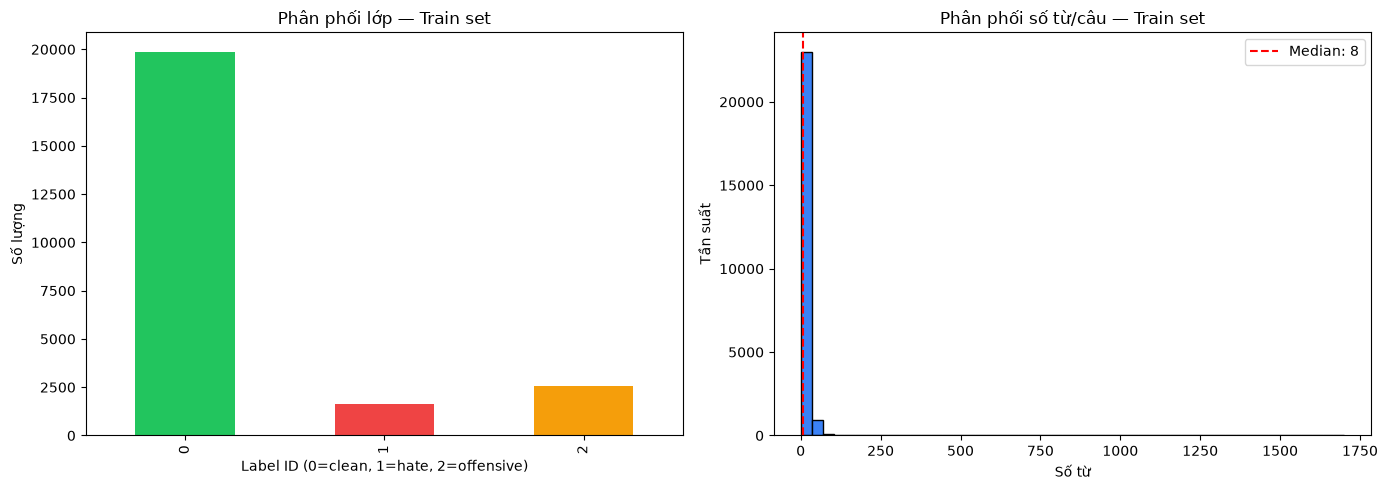


MẪU CÂU THEO CLASS

--- Label 0 (clean) ---
  • Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]]
  • Đậu Văn Cường giờ giống thằng sida hơn à
  • Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =))

--- Label 1 (hate) ---
  • Lúp lúp như chó .
  • Dạy bơi cho cá. Bơi thì đương nhiên nó bơi được vì nó là cá. Làm sao cho nó sống được mới là điều ng...
  • Ý thức còn ít hơn cả số tiền trong túi t

--- Label 2 (offensive) ---
  • Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái ...
  • CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.
  • Thế mà mình nói mấy thằng bắc kì, bọn đó lại bâu vô nói mình phân biệt!:D


In [3]:
# Cell 5 — EDA (Exploratory Data Analysis) ngắn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart phân phối
train_df['label_id'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#22c55e', '#ef4444', '#f59e0b']
)
axes[0].set_title('Phân phối lớp — Train set')
axes[0].set_xlabel('Label ID (0=clean, 1=hate, 2=offensive)')
axes[0].set_ylabel('Số lượng')

# Đếm tokens (sau khi lowercase + tách bằng space)
train_df['n_words'] = train_df['free_text'].str.split().str.len()
axes[1].hist(train_df['n_words'], bins=50, color='#3b82f6', edgecolor='black')
axes[1].set_title('Phân phối số từ/câu — Train set')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Tần suất')
axes[1].axvline(train_df['n_words'].median(), color='red', linestyle='--', label=f'Median: {train_df["n_words"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_distribution.png', dpi=120)
plt.show()

# In 2 câu mỗi class
print("\n" + "=" * 70)
print("MẪU CÂU THEO CLASS")
print("=" * 70)
for label in [0, 1, 2]:
    print(f"\n--- Label {label} ({LABEL_MAP[label]}) ---")
    samples = train_df[train_df['label_id'] == label]['free_text'].head(3).tolist()
    for s in samples:
        print(f"  • {s[:100]}{'...' if len(s) > 100 else ''}")

In [4]:
# Cell 6 — Preprocess toàn bộ dataset
print('⏳ Đang preprocess train set...')
t0 = time.time()
train_df['clean_text'] = train_df['free_text'].fillna('').apply(preprocess_text)
print(f'  ✓ Train: {time.time() - t0:.2f}s')

print('⏳ Đang preprocess val set...')
t0 = time.time()
val_df['clean_text'] = val_df['free_text'].fillna('').apply(preprocess_text)
print(f'  ✓ Val:   {time.time() - t0:.2f}s')

print('⏳ Đang preprocess test set...')
t0 = time.time()
test_df['clean_text'] = test_df['free_text'].fillna('').apply(preprocess_text)
print(f'  ✓ Test:  {time.time() - t0:.2f}s')

# Thống kê số câu bị rỗng sau preprocessing
empty_train = (train_df['clean_text'].str.len() == 0).sum()
empty_val = (val_df['clean_text'].str.len() == 0).sum()
empty_test = (test_df['clean_text'].str.len() == 0).sum()
print(f'\nSố câu rỗng sau preprocess:')
print(f'  Train: {empty_train}/{len(train_df)} ({empty_train/len(train_df)*100:.2f}%)')
print(f'  Val:   {empty_val}/{len(val_df)} ({empty_val/len(val_df)*100:.2f}%)')
print(f'  Test:  {empty_test}/{len(test_df)} ({empty_test/len(test_df)*100:.2f}%)')

# Show 3 examples
print('\nSo sánh trước/sau preprocessing:')
for i in range(3):
    print(f'\n  Raw: {train_df["free_text"].iloc[i][:80]}')
    print(f'  Clean: {train_df["clean_text"].iloc[i][:80]}')

⏳ Đang preprocess train set...


  ✓ Train: 30.22s
⏳ Đang preprocess val set...


  ✓ Val:   3.15s
⏳ Đang preprocess test set...


  ✓ Test:  8.09s

Số câu rỗng sau preprocess:
  Train: 178/24048 (0.74%)
  Val:   18/2672 (0.67%)
  Test:  55/6680 (0.82%)

So sánh trước/sau preprocessing:

  Raw: Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này qu
  Clean: làm fan cứng luôn nè love reaction quá quá cute coi mấy giờ quá hợp lí

  Raw: Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r 
  Clean: đúng bọn mắt híp lò xo thụt bên việt nam t cái cách 10 r bọn t gọi cái l

  Raw: Đậu Văn Cường giờ giống thằng sida hơn à
  Clean: đậu văn cường giờ giống thằng sida hơn


In [5]:
# Cell 7 — TF-IDF Vectorization
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

# Loại bỏ câu rỗng để tránh lỗi vectorizer
train_mask = train_df['clean_text'].str.len() > 0
val_mask = val_df['clean_text'].str.len() > 0
test_mask = test_df['clean_text'].str.len() > 0

print(f'Vectorizing trên {train_mask.sum()} train samples (loại {(~train_mask).sum()} rỗng)...')

# Fit trên train, transform trên cả 3
X_train_vec = tfidf.fit_transform(train_df.loc[train_mask, 'clean_text'])
X_val_vec = tfidf.transform(val_df.loc[val_mask, 'clean_text'])
X_test_vec = tfidf.transform(test_df.loc[test_mask, 'clean_text'])

y_train = train_df.loc[train_mask, 'label_id'].values
y_val = val_df.loc[val_mask, 'label_id'].values
y_test = test_df.loc[test_mask, 'label_id'].values

print(f'\nVector shapes:')
print(f'  X_train: {X_train_vec.shape} (sparse)')
print(f'  X_val:   {X_val_vec.shape}')
print(f'  X_test:  {X_test_vec.shape}')
print(f'\nVocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Density: {X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1]) * 100:.2f}%')

# Sample features
print('\nTop 20 features (đầu alphabet):')
features = tfidf.get_feature_names_out()
print(sorted(features)[:20])

Vectorizing trên 23870 train samples (loại 178 rỗng)...



Vector shapes:
  X_train: (23870, 29822) (sparse)
  X_val:   (2654, 29822)
  X_test:  (6625, 29822)

Vocabulary size: 29,822
Density: 0.04%

Top 20 features (đầu alphabet):
['0', '0 01', '0 cho', '0 lê', '0 lớp', '0 quạo', '0 sợ', '00', '00 00', '00 tỷ', '01', '01 2016', '01 tốt', '0155', '0155 tính', '0156', '0175', '0177', '0177 con', '02']
